In [3]:
# =========
#  Import 
# =========

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
      mean_absolute_error,
      mean_squared_error,
      r2_score
)

import joblib

In [4]:
# =============
#  Load dataset
# =============

df=pd.read_csv("C:/Users/Admin/Downloads/Laptop Price Prediction(ML Project)/Laptop_Price_Prediction_Dataset.csv")
df.head()

,Product_Name,Brand,RAM_GB,Storage_GB,Processor,GPU,Screen_Size_Inches,Operating_System,Weight_KG,Price
0,HP Laptop 0001,HP,4,1024,Intel Core i9,NVIDIA GTX 1650,14.0,Windows 11,2.3,91500
1,HP Laptop 0002,HP,64,2048,Intel Core i3,Intel UHD,13.3,Windows 10,1.6,110400
2,Dell Laptop 0003,Dell,64,512,AMD Ryzen 7,NVIDIA GTX 1650,16.0,macOS,2.5,131700
3,Lenovo Laptop 0004,Lenovo,32,1024,AMD Ryzen 3,AMD Radeon,14.0,macOS,1.4,86000
4,HP Laptop 0005,HP,16,1024,AMD Ryzen 3,Intel UHD,16.0,Windows 11,2.8,56600


In [5]:
# ====================
#  DATA UNDERSTANDING
# ====================

df.shape
print("Columns , Rows",df.shape)

Columns , Rows (1000, 10)


In [6]:
print("DatasetInformation")
df.info()

DatasetInformation
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Product_Name        1000 non-null   object 
 1   Brand               1000 non-null   object 
 2   RAM_GB              1000 non-null   int64  
 3   Storage_GB          1000 non-null   int64  
 4   Processor           1000 non-null   object 
 5   GPU                 1000 non-null   object 
 6   Screen_Size_Inches  1000 non-null   float64
 7   Operating_System    1000 non-null   object 
 8   Weight_KG           1000 non-null   float64
 9   Price               1000 non-null   int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [7]:
df.describe()

,RAM_GB,Storage_GB,Screen_Size_Inches,Weight_KG,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,24.528000,991.488000,15.303600,2.009900,104222.800000
std,21.460796,697.537538,1.424225,0.461373,33494.489113
min,4.000000,256.000000,13.300000,1.200000,26100.000000
25%,8.000000,512.000000,14.000000,1.600000,79750.000000
50%,16.000000,1024.000000,15.600000,2.000000,101700.000000
75%,32.000000,2048.000000,16.000000,2.400000,126325.000000
max,64.000000,2048.000000,17.300000,2.800000,224800.000000


In [8]:
df.isnull().sum()

Product_Name          0
Brand                 0
RAM_GB                0
Storage_GB            0
Processor             0
GPU                   0
Screen_Size_Inches    0
Operating_System      0
Weight_KG             0
Price                 0
dtype: int64

In [9]:
df.columns

Index(['Product_Name', 'Brand', 'RAM_GB', 'Storage_GB', 'Processor', 'GPU',
       'Screen_Size_Inches', 'Operating_System', 'Weight_KG', 'Price'],
      dtype='object')

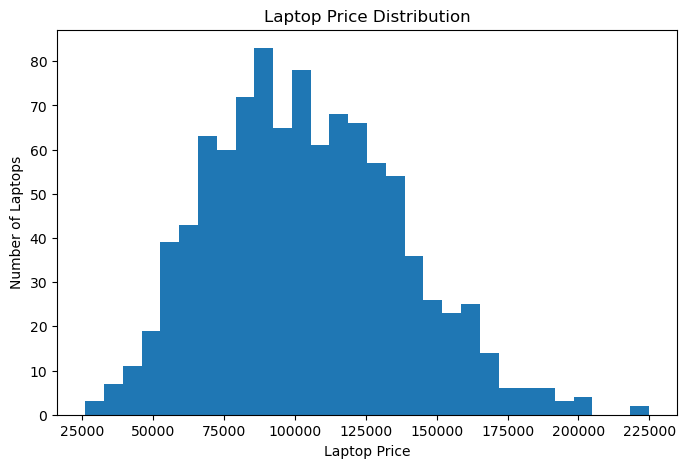

In [10]:
# ========================
#  EDA & VISUALIZATION
# ========================

# Price Distribution

plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=30)
plt.xlabel("Laptop Price")
plt.ylabel("Number of Laptops")
plt.title("Laptop Price Distribution")
plt.show()

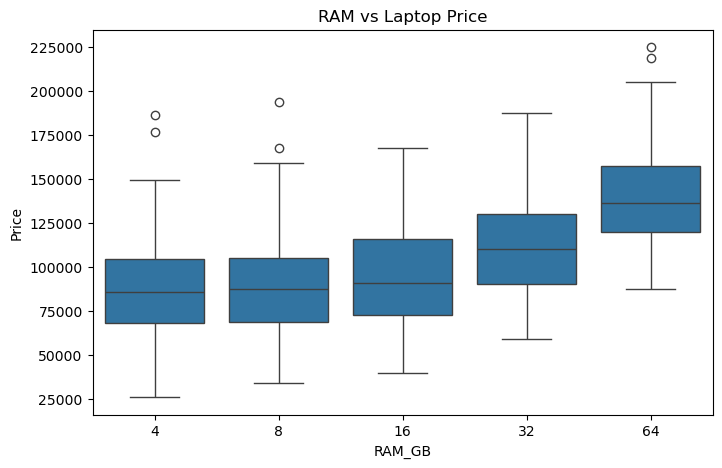

In [11]:
# RAM vs Price
         
plt.figure(figsize=(8,5))
sns.boxplot(x="RAM_GB",
        y="Price",
        data=df)
plt.title("RAM vs Laptop Price")
plt.show()

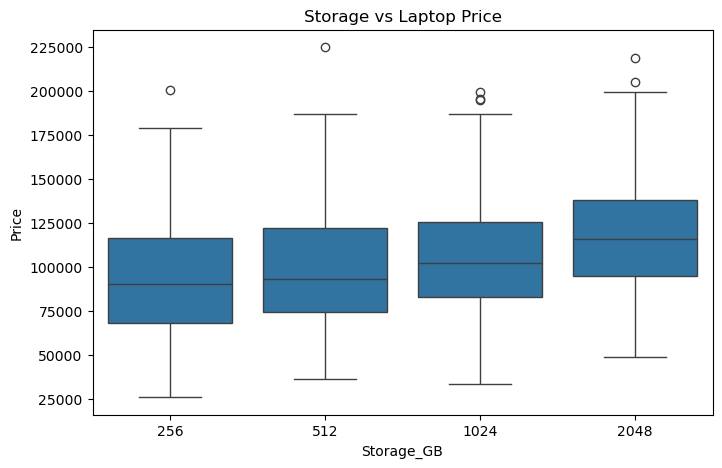

In [12]:
# Storage vs Price

plt.figure(figsize=(8,5))
sns.boxplot(x="Storage_GB",
            y="Price",
            data=df)
plt.title("Storage vs Laptop Price")
plt.show()

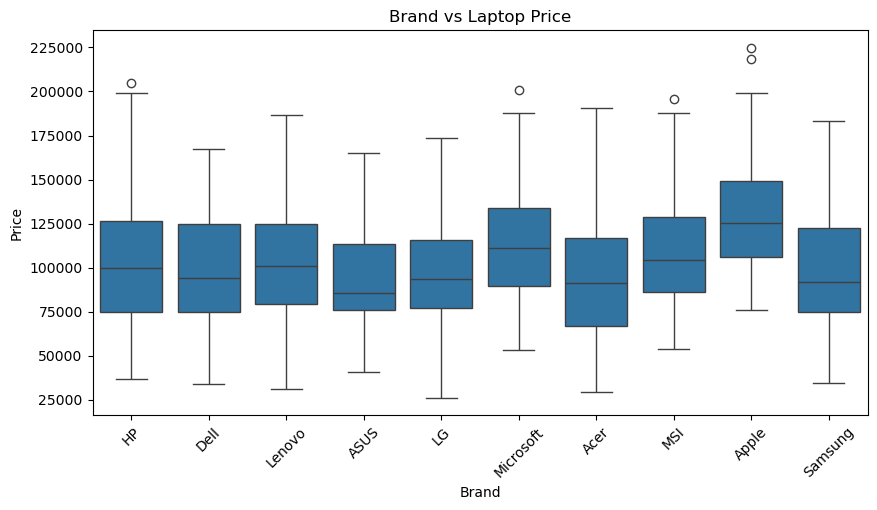

In [13]:
# Brand vs Price

plt.figure(figsize=(10,5))
sns.boxplot(x="Brand", 
            y="Price",
            data=df)
plt.xticks(rotation=45)
plt.title("Brand vs Laptop Price")
plt.show()

In [14]:
# ==============================
# Separate Features and Target
# ==============================

x = df.drop("Price",axis=1)
y = df["Price"]

print("Features:")
print(x.head())

Features:
         Product_Name   Brand  RAM_GB  Storage_GB      Processor  \
0      HP Laptop 0001      HP       4        1024  Intel Core i9   
1      HP Laptop 0002      HP      64        2048  Intel Core i3   
2    Dell Laptop 0003    Dell      64         512    AMD Ryzen 7   
3  Lenovo Laptop 0004  Lenovo      32        1024    AMD Ryzen 3   
4      HP Laptop 0005      HP      16        1024    AMD Ryzen 3   

               GPU  Screen_Size_Inches Operating_System  Weight_KG  
0  NVIDIA GTX 1650                14.0       Windows 11        2.3  
1        Intel UHD                13.3       Windows 10        1.6  
2  NVIDIA GTX 1650                16.0            macOS        2.5  
3       AMD Radeon                14.0            macOS        1.4  
4        Intel UHD                16.0       Windows 11        2.8  


In [15]:
print("\nTarget:")
print(y.head())


Target:
0     91500
1    110400
2    131700
3     86000
4     56600
Name: Price, dtype: int64


In [16]:
# ===========================================
# Identify Numerical and Categorical Columns
# ===========================================

categorical_columns = x.select_dtypes(include=["object"]).columns
numerical_columns = x.select_dtypes(exclude=["object"]).columns
print("Categorical Columns:")
print(list(categorical_columns))
print("\nNumerical Columns:")
print(list(numerical_columns))

Categorical Columns:
['Product_Name', 'Brand', 'Processor', 'GPU', 'Operating_System']

Numerical Columns:
['RAM_GB', 'Storage_GB', 'Screen_Size_Inches', 'Weight_KG']


In [17]:
# =================
# Train Test Split
# =================

X_train,X_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)
print("X_train :",X_train.shape)
print("X_test :",X_test.shape)
print("Y_train :",y_train.shape)
print("Y_test :",y_test.shape)

X_train : (800, 9)
X_test : (200, 9)
Y_train : (800,)
Y_test : (200,)


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

In [19]:
# ========
# Models
# ========

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100,random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}
    

In [20]:
# ===================
#  MODEL EVALUATION
# ===================

Results={}
trained_models={}
for name,model in models.items():
    print("\nTrainings:", name)

    pipeline = Pipeline(
        steps=[
            ("Preprocessor", preprocessor),
            ("Model",model)
        ]
    )
    pipeline.fit(X_train, y_train)
    y_pred=pipeline.predict(X_test)
    mae=mean_absolute_error(y_test, y_pred)
    rmse=np.sqrt(
        mean_squared_error(y_test, y_pred)
        )
    r2=r2_score(y_test, y_pred)
    
    Results[name]={
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }
    trained_models[name]= pipeline

    print("MAE:",round(mae, 2))
    print("RMSE:",round(rmse, 2))
    print("R2 Score:",round(r2,4))


Trainings: Linear Regression
MAE: 2484.17
RMSE: 2896.26
R2 Score: 0.9925

Trainings: Decision Tree
MAE: 12104.0
RMSE: 15671.46
R2 Score: 0.7799

Trainings: Random Forest
MAE: 8714.38
RMSE: 11742.71
R2 Score: 0.8764

Trainings: Gradient Boosting
MAE: 4678.92
RMSE: 6109.93
R2 Score: 0.9665


In [21]:
# ==================
# Model Comparison
# ==================

comparison = pd.DataFrame(Results).T
print("\nModel Comparison")
print(comparison)


Model Comparison
                            MAE          RMSE  R2 Score
Linear Regression   2484.172554   2896.263202  0.992481
Decision Tree      12104.000000  15671.461323  0.779856
Random Forest       8714.380000  11742.710521  0.876398
Gradient Boosting   4678.920089   6109.925528  0.966537


In [22]:
best_model_name = comparison["R2 Score"].idxmax()
print("Best Model:")
print(best_model_name)
best_model = trained_models[best_model_name]

Best Model:
Linear Regression


In [23]:
best_r2 = comparison.loc[
    best_model_name,
    "R2 Score"
]

best_mae = comparison.loc[
    best_model_name,
    "MAE"
]

best_rmse = comparison.loc[
    best_model_name,
    "RMSE"
] 

print("BEST MODEL PERFORMANCE :")
print("\nModel:", best_model_name)
print("R2 Score:", round(best_r2, 4))
print("MAE:", round(best_mae,2))
print("RMSE:",round(best_rmse, 2))

BEST MODEL PERFORMANCE :

Model: Linear Regression
R2 Score: 0.9925
MAE: 2484.17
RMSE: 2896.26


In [24]:
joblib.dump(
    best_model,
    "Laptop_Price_Prediction_Model.pkt"
)
print("Best model saved successfully!")

Best model saved successfully!


In [25]:
loaded_model = joblib.load(
    "Laptop_Price_Prediction_Model.pkt"
)
print("Model loaded successfully!")

Model loaded successfully!


In [26]:
new_laptop = pd.DataFrame({
    "Product_Name": ["HP 15"],
    "Brand": ["Dell"],
    "RAM_GB": [16],
    "Storage_GB": [512],
    "Processor": ["Intel Core i5"],
    "GPU": ["Intel Iris Xe"],
    "Screen_Size_Inches": [15.6],
    "Operating_System": ["Window 11"],
    "Weight_KG": [1.8]
})    

In [27]:
predicted_price = loaded_model.predict(new_laptop)
print("Predicted Laptop Price: ₹",
      round(predicted_price[0], 2)
     )


Predicted Laptop Price: ₹ 63093.76


In [28]:
brand = input("Enter Brand: ")
ram = int(input("Enter RAM (GB): "))
storage = int(input("Enter Storage (GB): "))
processor = input("Enter Processor: ")
gpu = input("Enter GPU: ")
screen = float(
    input("Enter Screen Size (inches): ")
)
os = input("Enter Operating Sysytem: ")
weight = float(
    input("Enter Weight(KG):")
)


Enter Brand:  HD
Enter RAM (GB):  724
Enter Storage (GB):  500
Enter Processor:  intel core i5
Enter GPU:  intel itis xe
Enter Screen Size (inches):  17.6
Enter Operating Sysytem:  window 11
Enter Weight(KG): 2.2


In [31]:
user_data = pd.DataFrame({
    "Product_Name": ["Laptop"],
    "Brand": [brand],
    "RAM_GB": [ram],
    "Storage_GB": [storage],
    "Processor": [processor],
    "GPU": [gpu],
    "Screen_Size_Inches": [screen],
    "Operating_System": [os],
    "Weight_KG": [weight]
})

In [36]:
prediction = loaded_model.predict(user_data)

print("\n============================")
print("   LAPTOP PRICE PREDICTION")
print("=============================")
print(
    "Predicted Price: ₹",
    round(prediction[0],2)
)


   LAPTOP PRICE PREDICTION
Predicted Price: ₹ 727832.61
